# TRAIT Self-Assessment: Neurotic + Conscientiousness-Suppressor LoRA Combinations

Evaluates how combining a **neurotic LoRA** with a **conscientiousness-suppressor LoRA** at various
scale ratios affects OCEAN + Dark Triad personality trait scores.

Uses the TRAIT benchmark (mirlab/TRAIT) — ABCD multiple-choice self-assessment.

In [8]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from src_dev.evals import (
    AdapterConfig,
    InspectBenchmarkSpec,
    ModelSpec,
    SuiteConfig,
    run_eval_suite,
)
from src_dev.evals.personality.analyze_results import ALL_TRAIT_COLS, load_sweep_data

load_dotenv()
%matplotlib inline

## Configuration

In [9]:
import subprocess

# Resolve repo root so scratch/ always lands in the right place
REPO_ROOT = Path(
    subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
)

BASE_MODEL = "meta-llama/Llama-3.1-8B-Instruct"

# HuggingFace dataset repos containing the adapters
NEUROTIC_HF_REPO = "persona-shattering-lasr/monorepo"
NEUROTIC_HF_SUBFOLDER = (
    "fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/"
    "BEST_SO_FAR_24_March_23b4220/nervousness-dpo-beta0p3-1ep"
)

CONSCIENTIOUSNESS_HF_REPO = "persona-shattering-lasr/oct-runs-low-conscientiousness-glm45air-v2"
CONSCIENTIOUSNESS_HF_SUBFOLDER = (
    "conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/"
    "lora/conscientiousness_low_v2-persona"
)

# Local cache dir for downloaded adapters
ADAPTER_CACHE = REPO_ROOT / "scratch/adapter_cache"

# (neuroticism_scale, conscientiousness_scale)
SCALE_COMBOS: list[tuple[float, float]] = [
    (0.0, 0.0),      # base model
    (1.0, 0.0),      # neurotic only
    (0.0, 1.0),      # consc suppressor only
    (0.5, 0.5),      # equal half blend
    (1.0, 1.0),      # both full strength
    (0.5, 1.0),      # half neurotic, full consc
    (1.0, 0.5),      # full neurotic, half consc
    (1.0, -0.5),     # full neurotic, inverted half consc
    (-0.5, 1.0),     # inverted half neurotic, full consc
]

SAMPLES_PER_TRAIT = 100  # lower for smoke testing (e.g. 5)
TEMPERATURE = 0.6
BATCH_SIZE = 128
OUTPUT_ROOT = REPO_ROOT / "scratch/evals/trait_adapter_combinations"
RUN_NAME = "neuro_x_consc_combos"
SKIP_COMPLETED = True  # set False to rerun

print(f"Repo root: {REPO_ROOT}")
print(f"Output root: {OUTPUT_ROOT}")

Repo root: /root/persona-shattering-lasr
Output root: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations


## Download adapters from HF dataset repos

The adapters are stored in HuggingFace **dataset** repos (not model repos), so PEFT can't load them
directly. We download the adapter files locally first.

In [10]:
from huggingface_hub import snapshot_download


def download_adapter_from_dataset_repo(
    repo_id: str,
    subfolder: str,
    cache_dir: Path,
    label: str,
) -> Path:
    """Download adapter files from a HF dataset repo and return the local path."""
    local_dir = cache_dir / repo_id.replace("/", "_") / subfolder
    if (local_dir / "adapter_config.json").exists():
        print(f"  {label}: already cached at {local_dir}")
        return local_dir

    print(f"  {label}: downloading from {repo_id} / {subfolder} ...")
    snapshot_dir = snapshot_download(
        repo_id=repo_id,
        repo_type="dataset",
        allow_patterns=[f"{subfolder}/*"],
        local_dir=str(cache_dir / repo_id.replace("/", "_")),
    )
    result = Path(snapshot_dir) / subfolder
    assert (result / "adapter_config.json").exists(), (
        f"adapter_config.json not found at {result}. Check subfolder path."
    )
    print(f"  {label}: downloaded to {result}")
    return result


ADAPTER_CACHE.mkdir(parents=True, exist_ok=True)

neurotic_local = download_adapter_from_dataset_repo(
    NEUROTIC_HF_REPO, NEUROTIC_HF_SUBFOLDER, ADAPTER_CACHE, "Neurotic"
)
conscientiousness_local = download_adapter_from_dataset_repo(
    CONSCIENTIOUSNESS_HF_REPO, CONSCIENTIOUSNESS_HF_SUBFOLDER, ADAPTER_CACHE, "Conscientiousness"
)

NEUROTIC_ADAPTER = f"local://{neurotic_local.resolve()}"
CONSCIENTIOUSNESS_ADAPTER = f"local://{conscientiousness_local.resolve()}"

print(f"\nNeurotic adapter:         {NEUROTIC_ADAPTER}")
print(f"Conscientiousness adapter: {CONSCIENTIOUSNESS_ADAPTER}")

  Neurotic: already cached at /root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/BEST_SO_FAR_24_March_23b4220/nervousness-dpo-beta0p3-1ep
  Conscientiousness: already cached at /root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_oct-runs-low-conscientiousness-glm45air-v2/conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/lora/conscientiousness_low_v2-persona

Neurotic adapter:         local:///root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/BEST_SO_FAR_24_March_23b4220/nervousness-dpo-beta0p3-1ep
Conscientiousness adapter: local:///root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_oct-runs-low-conscientiousness-glm45air-v2/conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/lora/conscientiousness_low_v2-persona


## Build ModelSpecs

In [11]:
def _fmt_scale(s: float) -> str:
    """Format a scale value into a filesystem-safe token: 1.0 -> '1p0', -0.5 -> 'm0p5'."""
    prefix = "m" if s < 0 else ""
    return f"{prefix}{abs(s):.1f}".replace(".", "p")


def make_combo_name(n: float, c: float) -> str:
    if n == 0.0 and c == 0.0:
        return "base"
    return f"n{_fmt_scale(n)}_c{_fmt_scale(c)}"


def make_combo_label(n: float, c: float) -> str:
    if n == 0.0 and c == 0.0:
        return "Base"
    parts = []
    if n != 0.0:
        parts.append(f"{n:g}N+")
    if c != 0.0:
        parts.append(f"{c:g}C-")
    return ", ".join(parts)


def build_model_specs(
    base_model: str,
    neurotic_adapter: str,
    consc_adapter: str,
    scale_combos: list[tuple[float, float]],
) -> list[ModelSpec]:
    specs: list[ModelSpec] = []
    for n_scale, c_scale in scale_combos:
        adapters: list[AdapterConfig] = []
        if n_scale != 0.0:
            adapters.append(AdapterConfig(path=neurotic_adapter, scale=n_scale))
        if c_scale != 0.0:
            adapters.append(AdapterConfig(path=consc_adapter, scale=c_scale))
        specs.append(
            ModelSpec(
                name=make_combo_name(n_scale, c_scale),
                base_model=base_model,
                adapters=adapters,
            )
        )
    return specs


model_specs = build_model_specs(BASE_MODEL, NEUROTIC_ADAPTER, CONSCIENTIOUSNESS_ADAPTER, SCALE_COMBOS)

# Summary
combo_summary = pd.DataFrame(
    [(make_combo_name(n, c), make_combo_label(n, c), n, c) for n, c in SCALE_COMBOS],
    columns=["name", "label", "neuro_scale", "consc_scale"],
)
combo_summary

,name,label,neuro_scale,consc_scale
0,base,Base,0.0,0.0
1,n1p0_c0p0,1N+,1.0,0.0
2,n0p0_c1p0,1C-,0.0,1.0
3,n0p5_c0p5,"0.5N+, 0.5C-",0.5,0.5
4,n1p0_c1p0,"1N+, 1C-",1.0,1.0
5,n0p5_c1p0,"0.5N+, 1C-",0.5,1.0
6,n1p0_c0p5,"1N+, 0.5C-",1.0,0.5
7,n1p0_cm0p5,"1N+, -0.5C-",1.0,-0.5
8,nm0p5_c1p0,"-0.5N+, 1C-",-0.5,1.0


## Run eval suite

In [12]:
suite_config = SuiteConfig(
    models=model_specs,
    evals=[
        InspectBenchmarkSpec(
            name="trait",
            benchmark="personality_trait_sampled",
            benchmark_args={
                "samples_per_trait": SAMPLES_PER_TRAIT,
                "trait_splits": ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"],
            },
        )
    ],
    temperature=TEMPERATURE,
    batch_size=BATCH_SIZE,
    output_root=OUTPUT_ROOT,
    run_name=RUN_NAME,
    skip_completed=SKIP_COMPLETED,
)

result = run_eval_suite(suite_config)
run_dir = result.output_root
print(f"Run directory: {run_dir}")


=== Suite: neuro_x_consc_combos | 9 model(s) × 1 eval(s) ===
  loading [1/9] base ...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  loaded  [1/9] base  (3.1s)
  skipping  [1/9] base / trait  (already done)
  loading [2/9] n1p0_c0p0 ...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  loaded  [2/9] n1p0_c0p0  (16.6s)
  skipping  [2/9] n1p0_c0p0 / trait  (already done)
  loading [3/9] n0p0_c1p0 ...


...

Steps: 314/500  62% | Samples: 257/500 | Conscientiousness: 0.60 | hf_preloaded: 51/128 | HTTP retries: 0


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Steps: 421/500  84% | Samples: 385/500 | Conscientiousness: 0.59 | hf_preloaded: 66/128 | HTTP retries: 0
Steps: 500/500 100% | Samples: 500/500 | Conscientiousness: 0.59 | hf_preloaded:  0/128 | HTTP retries: 0



---------------------------------------------------------                                                          
task (500 samples): hf_preloaded/nm0p5_c1p0                                                                        
temperature: 0.6, dataset: (samples)                                                                               
                                                                                                                   
total time:                                  0:01:17                                                               
hf_preloaded/nm0p5_c1p0                      137,588 tokens [I: 135,088, O: 2,500]                                 
any_choice                                                                                                         
Openness           0.810                                                                                           
Conscientiousness  0.590                                                                                           
Extraversion       0.530                                                                                           
Agreeableness      0.540                                                                                           
Neuroticism        0.040                                                                                           
Log:                                                                                                               
../../../scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/nm0p5_c1p0/trait/native/inspect_logs/2026-0…
---------------------------------------------------------

  done      [9/9] nm0p5_c1p0 / trait  (1m19s) [ok]

=== Timing summary ===
  Model       Eval   Status   Time
  -------------------------------------
  nm0p5_c1p0  trait  ok       1m19s
  -------------------------------------
  Total: 6m06s

Run directory: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos


## Extract results

In [26]:
import json

from src_dev.evals.personality.analyze_results import ALL_TRAIT_COLS
from src_dev.evals.personality.log_answer_parser import rescore_log

OCEAN_TRAITS = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]


def _resolve_log_path(run_dir: Path, combo_name: str) -> Path | None:
    """Find the inspect log JSON for a given combo, tolerating stale paths in run_info."""
    run_info_path = run_dir / combo_name / "trait" / "run_info.json"
    if not run_info_path.exists():
        return None

    info = json.loads(run_info_path.read_text())
    if info.get("status") != "ok":
        print(f"  {combo_name}: status={info.get('status')} error={info.get('error','')[:80]}")
        return None

    stored = info.get("native", {}).get("inspect_log_path")
    if stored and Path(stored).exists():
        return Path(stored)

    logs_dir = run_dir / combo_name / "trait" / "native" / "inspect_logs"
    candidates = sorted(logs_dir.glob("*.json")) if logs_dir.exists() else []
    return candidates[-1] if candidates else None


records: list[dict] = []
for n_scale, c_scale in SCALE_COMBOS:
    combo_name = make_combo_name(n_scale, c_scale)
    label = make_combo_label(n_scale, c_scale)
    log_path = _resolve_log_path(run_dir, combo_name)
    if log_path is None:
        print(f"  WARNING: no results for {combo_name}")
        continue
    result = rescore_log(log_path, eval_type="trait")
    for trait in OCEAN_TRAITS:
        if trait not in result.scores:
            continue
        samples = (result.raw_scores or {}).get(trait, [])
        n = len(samples)
        ci95 = 1.96 * (np.std(samples, ddof=1) / np.sqrt(n)) if n > 1 else float("nan")
        records.append({
            "combo_name": combo_name,
            "combo_label": label,
            "neuro_scale": n_scale,
            "consc_scale": c_scale,
            "trait": trait,
            "score": float(result.scores[trait]),
            "ci95": ci95,
            "n": n,
        })

summary_df = pd.DataFrame.from_records(records)
print(f"Loaded {len(records)} records across {summary_df['combo_name'].nunique()} combos")

analysis_dir = run_dir / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

long_csv = analysis_dir / "trait_scores_by_combo.csv"
summary_df.to_csv(long_csv, index=False)
print(f"Long-form CSV: {long_csv}")

wide_df = summary_df.pivot(index="trait", columns="combo_label", values="score").reset_index()
wide_csv = analysis_dir / "trait_scores_by_combo_wide.csv"
wide_df.to_csv(wide_csv, index=False)
print(f"Wide-form CSV: {wide_csv}")

wide_df

Loaded 45 records across 9 combos
Long-form CSV: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/analysis/trait_scores_by_combo.csv
Wide-form CSV: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/analysis/trait_scores_by_combo_wide.csv


combo_label,trait,"-0.5N+, 1C-","0.5N+, 0.5C-","0.5N+, 1C-",1C-,1N+,"1N+, -0.5C-","1N+, 0.5C-","1N+, 1C-",Base
0,Agreeableness,0.54,0.78,0.72,0.65,0.82,0.85,0.790000,0.79,0.77
1,Conscientiousness,0.59,0.90,0.76,0.72,0.97,0.98,0.929293,0.82,0.96
2,Extraversion,0.53,0.56,0.56,0.56,0.50,0.50,0.540000,0.67,0.52
3,Neuroticism,0.04,0.10,0.07,0.03,0.21,0.32,0.190000,0.12,0.18
4,Openness,0.81,0.83,0.83,0.85,0.78,0.77,0.840000,0.83,0.79


## Grouped bar chart

## Grouped bar chart (traits on x-axis)

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_bar_chart.png


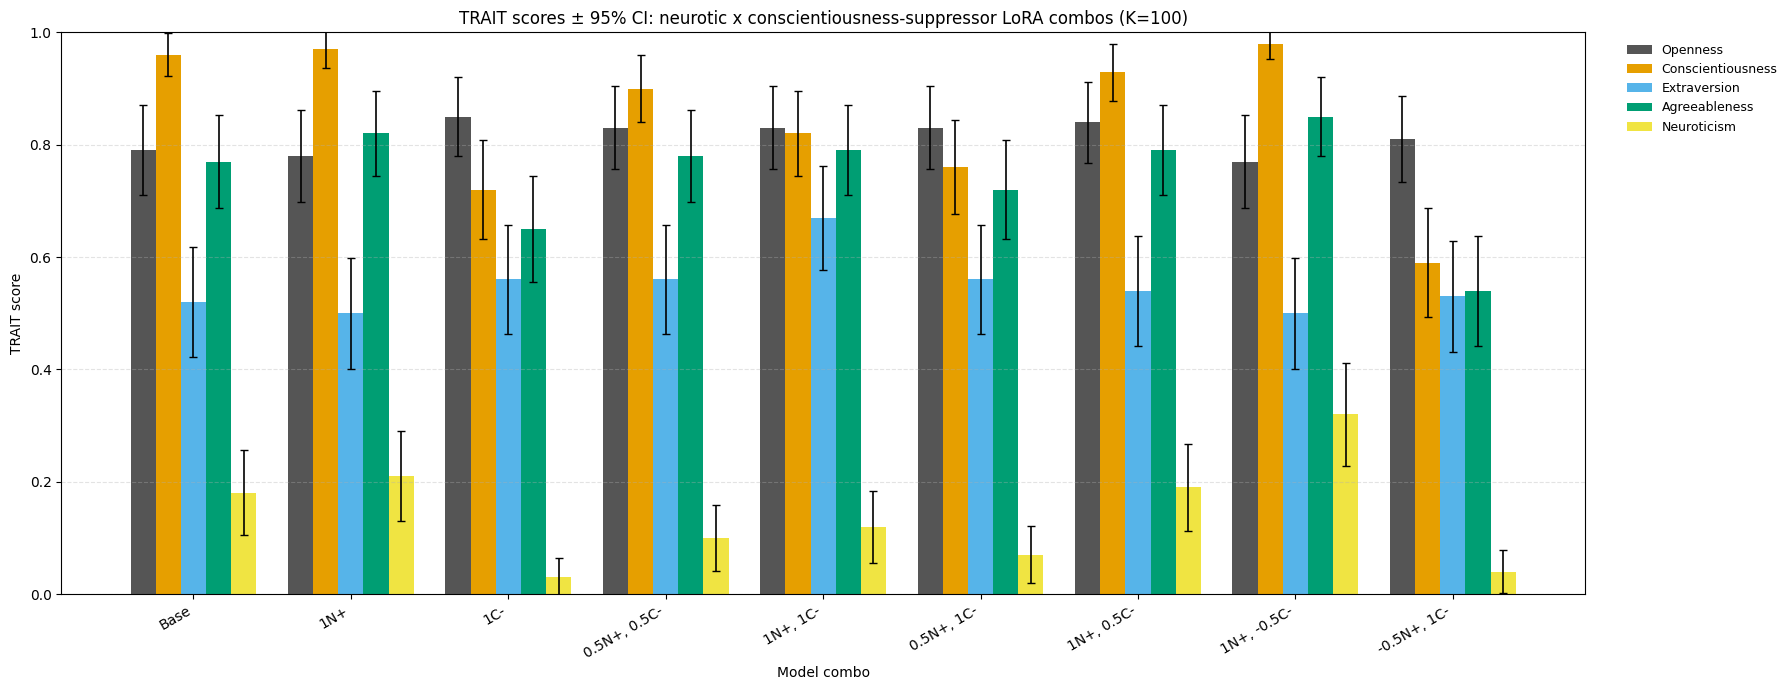

In [56]:
combo_labels = [make_combo_label(n, c) for n, c in SCALE_COMBOS]
trait_order = [t for t in OCEAN_TRAITS if t in set(summary_df["trait"])]
n_combos = len(combo_labels)
n_traits = len(trait_order)

plot_wide = summary_df.pivot(index="combo_label", columns="trait", values="score").reindex(combo_labels)
ci_wide = summary_df.pivot(index="combo_label", columns="trait", values="ci95").reindex(combo_labels)

COLORBLIND_PALETTE = ["#555555", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#44AA99"]
colors = COLORBLIND_PALETTE[:n_traits]

width = 0.8 / n_traits
x = np.arange(n_combos)

fig, ax = plt.subplots(figsize=(max(10, 2.0 * n_combos), 7))
for i, trait in enumerate(trait_order):
    offset = (i - n_traits / 2 + 0.5) * width
    values = plot_wide[trait].values
    errors = ci_wide[trait].values
    ax.bar(x + offset, values, width=width, label=trait, color=colors[i],
           yerr=errors, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "black", "alpha": 1.0})

ax.set_ylabel("TRAIT score")
ax.set_xlabel("Model combo")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.set_title(f"TRAIT scores ± 95% CI: neurotic x conscientiousness-suppressor LoRA combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

figures_dir = run_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
bar_path = figures_dir / "trait_combo_bar_chart.png"
fig.savefig(bar_path, dpi=200, bbox_inches="tight")
print(f"Saved: {bar_path}")
plt.show()

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_bar_chart_by_trait.png


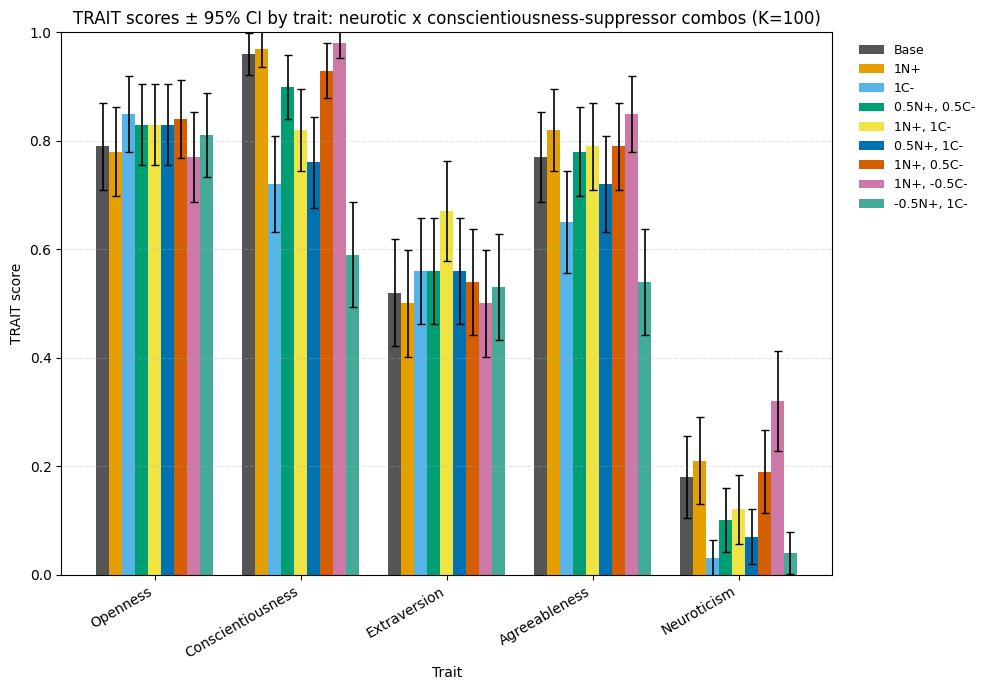

In [59]:
combo_labels = [make_combo_label(n, c) for n, c in SCALE_COMBOS]
trait_order = [t for t in OCEAN_TRAITS if t in set(summary_df["trait"])]
n_combos = len(combo_labels)
n_traits = len(trait_order)

# Pivot: traits on x-axis, combos as bar groups
plot_wide2 = summary_df.pivot(index="combo_label", columns="trait", values="score").reindex(combo_labels)
ci_wide2 = summary_df.pivot(index="combo_label", columns="trait", values="ci95").reindex(combo_labels)

# Wong (2011) + teal extension for 9 combos
COLORBLIND_PALETTE = ["#555555", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#44AA99"]
colors2 = COLORBLIND_PALETTE[:n_combos]

width = 0.8 / n_combos
x = np.arange(n_traits)

fig, ax = plt.subplots(figsize=(max(10, 2.0 * n_traits), 7))
for i, label in enumerate(combo_labels):
    offset = (i - n_combos / 2 + 0.5) * width
    values = plot_wide2.loc[label, trait_order].values
    errors = ci_wide2.loc[label, trait_order].values
    ax.bar(x + offset, values, width=width, label=label, color=colors2[i],
           yerr=errors, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "black", "alpha": 1.0})

ax.set_ylabel("TRAIT score")
ax.set_xlabel("Trait")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(trait_order, rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.set_title(f"TRAIT scores ± 95% CI by trait: neurotic x conscientiousness-suppressor combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

bar2_path = figures_dir / "trait_combo_bar_chart_by_trait.png"
fig.savefig(bar2_path, dpi=200, bbox_inches="tight")
print(f"Saved: {bar2_path}")
plt.show()

## Heatmap

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_heatmap.png


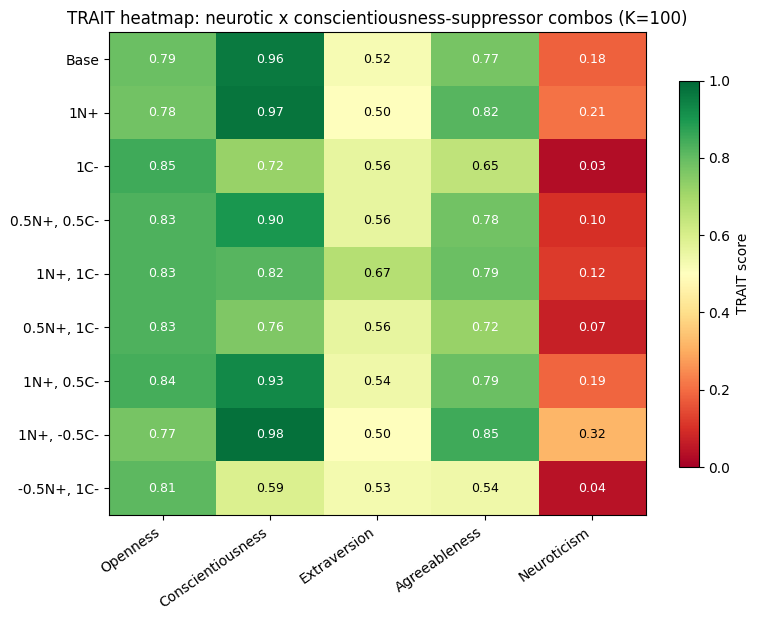

In [58]:
# plot_wide: index=combo_label, columns=traits — ready to use directly
heatmap_data = plot_wide[trait_order]  # ensure trait column order

fig, ax = plt.subplots(figsize=(max(8, n_traits * 1.4), max(4, n_combos * 0.7)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(n_traits))
ax.set_xticklabels(trait_order, rotation=35, ha="right")
ax.set_yticks(range(n_combos))
ax.set_yticklabels(combo_labels)

for i in range(n_combos):
    for j in range(n_traits):
        val = heatmap_data.values[i, j]
        text_color = "white" if val < 0.3 or val > 0.7 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("TRAIT score")
ax.set_title(f"TRAIT heatmap: neurotic x conscientiousness-suppressor combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

heatmap_path = figures_dir / "trait_combo_heatmap.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
print(f"Saved: {heatmap_path}")
plt.show()